In [1]:
import shutil
import pathlib

from Process_Raw_Rainfall_Data.compare_rainfall_files import compare_files
from Process_Raw_Rainfall_Data.process_wide_format_rainfall import run_wide_format_processing
from Process_Raw_Rainfall_Data.rainfall_daily_to_monthly import process_rainfall_directory
from Process_Raw_Rainfall_Data.rainfall_monthly_coverage_viz import rainfall_monthly_coverage_viz

In [2]:
RAINFALL_DIR = pathlib.Path('raw_data/rainfall')
RAINFALL_ADDED_DIR = pathlib.Path('raw_data/rainfall_added')
LOG_FILE = pathlib.Path('raw_data/rainfall_comparison.log')
WIDE_FILE = pathlib.Path('raw_data/daily_wide_4302025.csv')

In [3]:
# Takes in a wide format file and processes it into individual station files
run_wide_format_processing(WIDE_FILE, RAINFALL_ADDED_DIR)

Reading input file: raw_data/daily_wide_4302025.csv
Processing station: aasu_UH
Processing station: aasufou80
Processing station: aasufou90
Processing station: afono_UH
Processing station: airport5101
Processing station: airport80
Processing station: aoloafou
Processing station: aua
Processing station: aunuu
Processing station: aunuu_UH
Processing station: fagaitua
Processing station: GML_SMO
Processing station: iliili
Processing station: malaeimi
Processing station: malaeimi_1691
Processing station: maloata
Processing station: masefau
Processing station: matatula
Processing station: mt_alava
Processing station: pioa_afono
Processing station: poloa_UH
Processing station: satala
Processing station: siufaga_WRCC
Processing station: toa_ridge_WRCC
Processing station: vaipito_res
Processing station: vaipito_UH
Processing station: vaipito2000
Writing 2922 records to raw_data/rainfall_added/aasu_UH.csv
Writing 7671 records to raw_data/rainfall_added/aasufou80.csv
Writing 731 records to raw_d

In [4]:
compare_files(RAINFALL_DIR, RAINFALL_ADDED_DIR, LOG_FILE)

Starting rainfall data comparison

Files only in added directory:
  - GML_SMO.csv
  - aasu_UH.csv
  - afono_UH.csv
  - aunuu_UH.csv
  - poloa_UH.csv
  - vaipito_UH.csv

Found 21 common files to compare


Comparing maloata.csv:
  Found 423 common dates between files
  All common dates have matching values
  Found 308 dates only in added file

Comparing malaeimi.csv:
  Found 426 common dates between files
  All common dates have matching values
  Found 305 dates only in added file

Comparing satala.csv:
  Found 3952 common dates between files
  All common dates have matching values
  Found 431 dates only in added file

Comparing aua.csv:
  Found 1050 common dates between files
  All common dates have matching values
  Found 411 dates only in added file

Comparing vaipito_res.csv:
  Found 6945 common dates between files
  All common dates have matching values
  Found 360 dates only in added file

Comparing masefau.csv:
  Found 866 common dates between files
  All common dates have matchin

Found a difference in the Ilili station between the raw data from Keri (RAINFALL_DIR) and the rainfall data from Derek (RAINFALL_ADDED_DIR). I went to the source and discovered the correct numbers are in the RAINFALL_DIR (raw_data/rainfall).

In [5]:
# Define source and destination directories
RAINFALL_CORRECTED_DIR = pathlib.Path('raw_data/rainfall_corrected')

# Create the destination directory if it doesn't exist
RAINFALL_CORRECTED_DIR.mkdir(parents=True, exist_ok=True)

# Copy all CSV files from rainfall_added except iliili.csv
for file in RAINFALL_ADDED_DIR.glob('*.csv'):
    if file.name.lower() != 'iliili.csv':  # Case-insensitive check
        shutil.copy2(file, RAINFALL_CORRECTED_DIR / file.name)

# Copy iliili.csv from the rainfall directory
iliili_src = RAINFALL_DIR / 'iliili.csv'
if iliili_src.exists():
    shutil.copy2(iliili_src, RAINFALL_CORRECTED_DIR / 'iliili.csv')
else:
    print(f"Warning: {iliili_src} not found. Skipping iliili.csv copy.")

print(f"Files copied to: {RAINFALL_CORRECTED_DIR.resolve()}")

Files copied to: /Users/jlee/Desktop/github/AS_rainfall/raw_data/rainfall_corrected


In [6]:
# Create monthly aggregated rainfall files for the RAINFALL_CORRECTED_DIR
RAINFALL_MONTHLY_DIR = 'Process_Raw_Rainfall_Data/output/monthly_rainfall'
process_rainfall_directory(input_dir=RAINFALL_CORRECTED_DIR, output_dir=RAINFALL_MONTHLY_DIR)

Processing rainfall data from raw_data/rainfall_corrected to Process_Raw_Rainfall_Data/output/monthly_rainfall
Processed: aasu_UH.csv -> aasu_UH_monthly.csv [1/27]
Processed: satala.csv -> satala_monthly.csv [2/27]
Processed: airport5101.csv -> airport5101_monthly.csv [3/27]
Processed: aunuu_UH.csv -> aunuu_UH_monthly.csv [4/27]
Processed: pioa_afono.csv -> pioa_afono_monthly.csv [5/27]
Processed: aua.csv -> aua_monthly.csv [6/27]
Processed: siufaga_WRCC.csv -> siufaga_WRCC_monthly.csv [7/27]
Processed: airport80.csv -> airport80_monthly.csv [8/27]
Processed: vaipito_res.csv -> vaipito_res_monthly.csv [9/27]
Processed: poloa_UH.csv -> poloa_UH_monthly.csv [10/27]
Processed: aasufou80.csv -> aasufou80_monthly.csv [11/27]
Processed: maloata.csv -> maloata_monthly.csv [12/27]
Processed: toa_ridge_WRCC.csv -> toa_ridge_WRCC_monthly.csv [13/27]
Processed: aasufou90.csv -> aasufou90_monthly.csv [14/27]
Processed: vaipito2000.csv -> vaipito2000_monthly.csv [15/27]
Processed: malaeimi.csv -> m

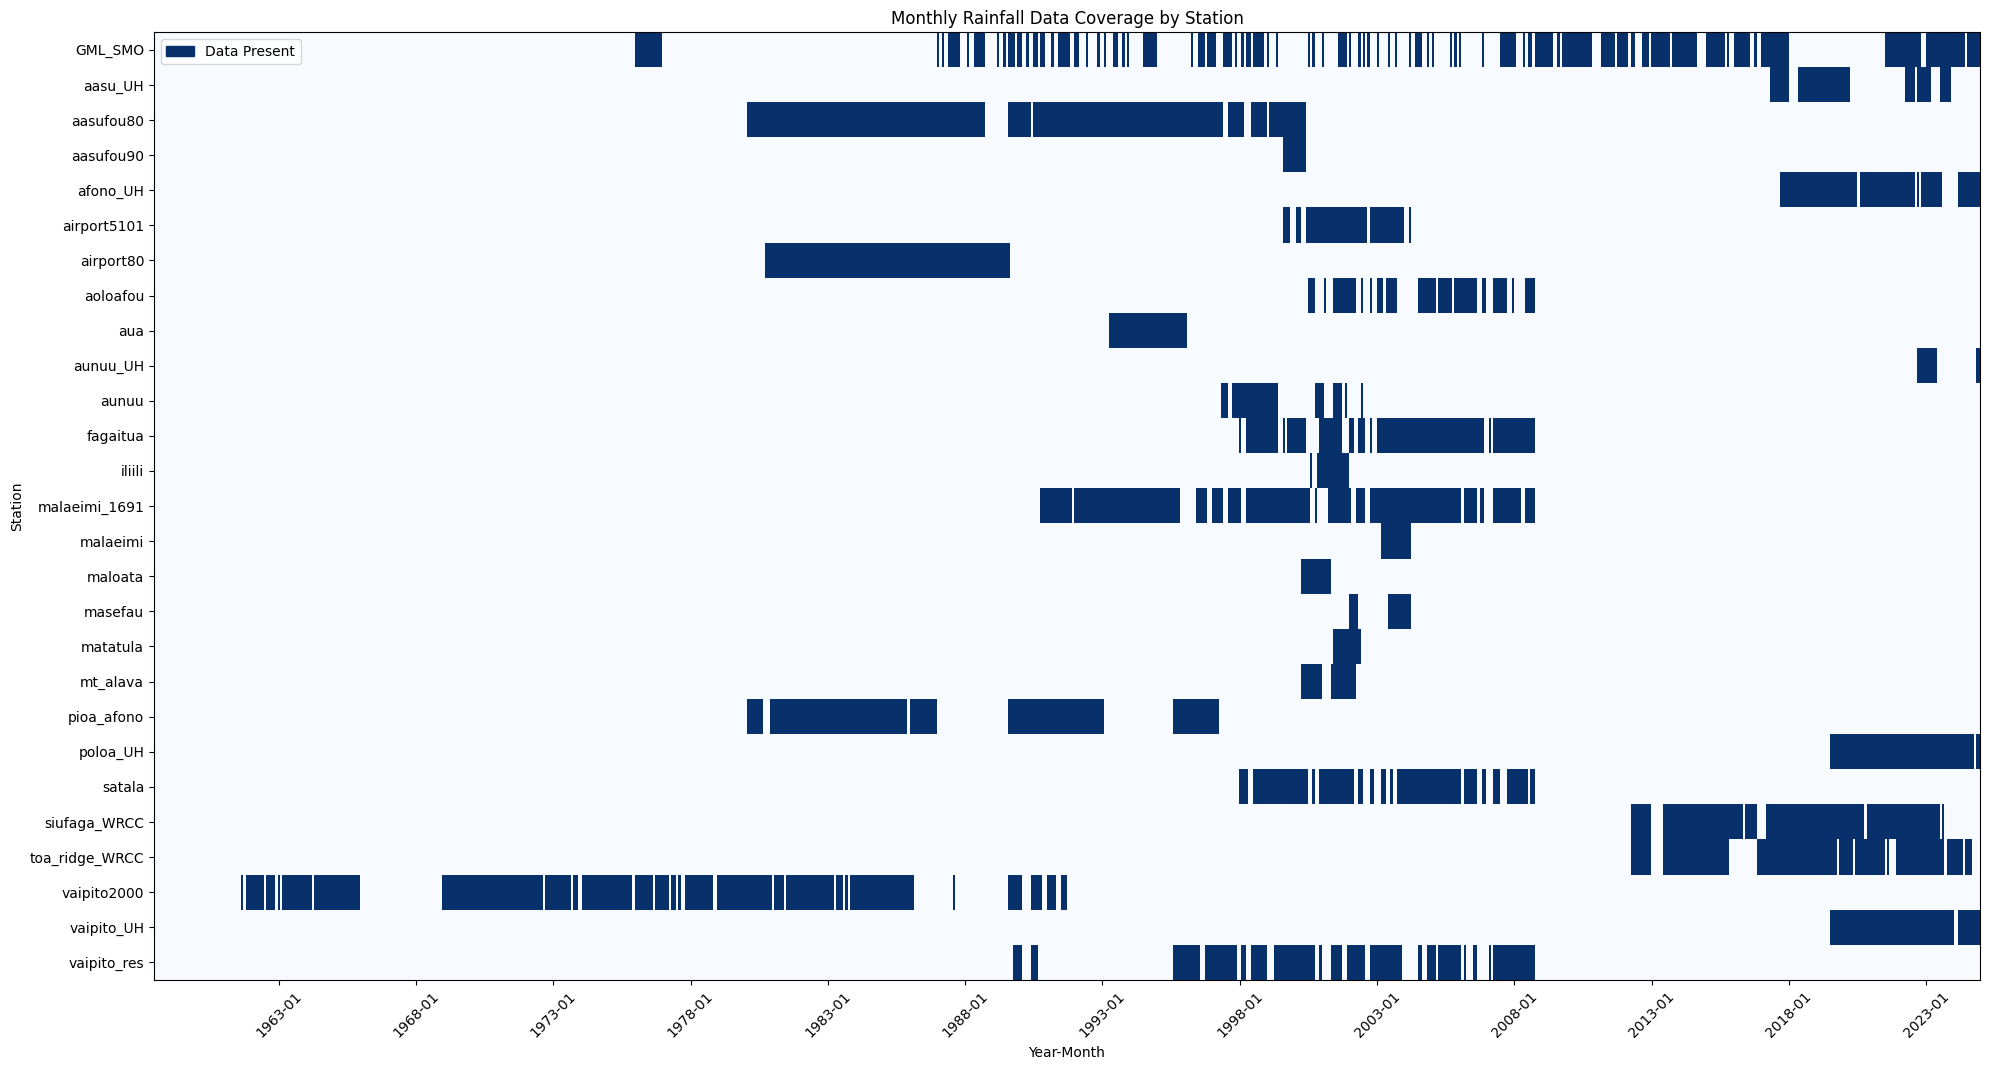

In [7]:
# Visualize monthly rainfall data coverage
RAINFALL_MONTHLY_VIZ_DIR = pathlib.Path('Process_Raw_Rainfall_Data/figures')
RAINFALL_MONTHLY_VIZ_DIR.mkdir(exist_ok=True)
rainfall_monthly_coverage_viz(RAINFALL_MONTHLY_DIR,RAINFALL_MONTHLY_VIZ_DIR)
